# Assignment 2 – AI/ML Applications in Civil Engineering

## Problem Description

A planar block of intact rock mass is failing along a discontinuity plane.  
The rock slope is inclined at β = 46° and the discontinuity plane makes an angle α = 40° with the horizontal.

Height of failing block:

h = 85 m

Mean rock properties:

• Cohesion (c) = 30 kPa  
• Unit weight (γ) = 24 kN/m³  
• Friction angle:

φ = 0.15Z + 25

For roll number **087**

φ = 38.05°

The parameters are assumed to follow **lognormal distributions** with coefficient of variation **0.10**.

The objectives are:

• Compute deterministic factor of safety  
• Perform probabilistic Monte Carlo simulation  
• Estimate probability of failure  
• Train ANN surrogate model  
• Evaluate model performance  
• Perform sensitivity analysis

### Imporing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.stats import lognorm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### Deterministic Factor of Safety

In [2]:
# Given values
c = 30
gamma = 24

alpha = np.radians(40)
beta = np.radians(46)

h = 85

phi = np.radians(38.05)

# Weight of block
W = (gamma*h**2/2)*(1/np.tan(alpha) - 1/np.tan(beta))

# Deterministic FOS
FOS_det = ((h/np.sin(alpha))*c + W*np.cos(alpha)*np.tan(phi))/(W*np.sin(alpha))

print("Deterministic Factor of Safety =", round(FOS_det,3))

Deterministic Factor of Safety = 1.248


### Statistical Model Specification

In [3]:
cov = 0.10

mean_c = 30
mean_gamma = 24
mean_tanphi = np.tan(phi)

def lognormal_params(mean,cov):
    
    sigma = np.sqrt(np.log(1 + cov**2))
    mu = np.log(mean) - sigma**2/2
    
    return mu,sigma

mu_c,sigma_c = lognormal_params(mean_c,cov)
mu_gamma,sigma_gamma = lognormal_params(mean_gamma,cov)
mu_tanphi,sigma_tanphi = lognormal_params(mean_tanphi,cov)

### Distribution of Input Variables

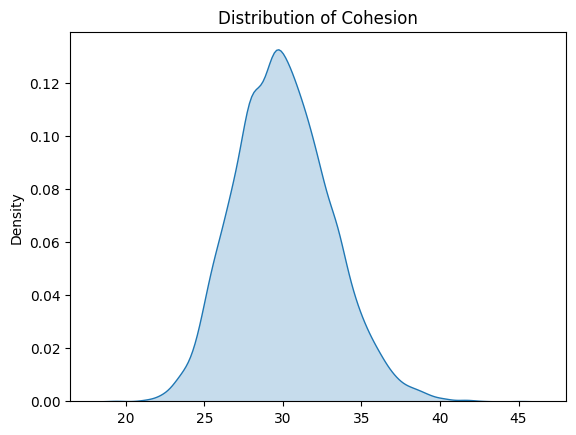

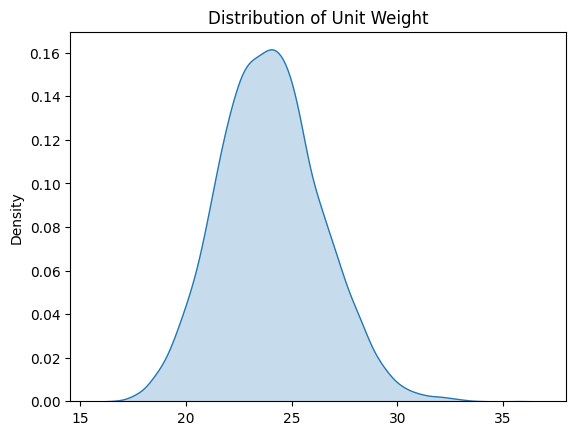

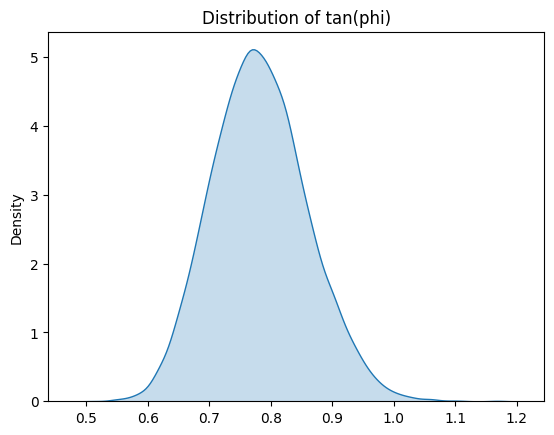

In [4]:
N = 10000

c_samples = np.random.lognormal(mu_c,sigma_c,N)
gamma_samples = np.random.lognormal(mu_gamma,sigma_gamma,N)
tanphi_samples = np.random.lognormal(mu_tanphi,sigma_tanphi,N)

sns.kdeplot(c_samples,fill=True)
plt.title("Distribution of Cohesion")
plt.show()

sns.kdeplot(gamma_samples,fill=True)
plt.title("Distribution of Unit Weight")
plt.show()

sns.kdeplot(tanphi_samples,fill=True)
plt.title("Distribution of tan(phi)")
plt.show()

### Monte Carlo Simulation


In [5]:
N = 500

c = np.random.lognormal(mu_c,sigma_c,N)
gamma = np.random.lognormal(mu_gamma,sigma_gamma,N)
tanphi = np.random.lognormal(mu_tanphi,sigma_tanphi,N)

phi = np.arctan(tanphi)

W = (gamma*h**2/2)*(1/np.tan(alpha) - 1/np.tan(beta))

FOS = ((h/np.sin(alpha))*c + W*np.cos(alpha)*np.tan(phi))/(W*np.sin(alpha))

### Distribution of Factor of Safety
The distribution of the factor of safety obtained from the Monte Carlo simulation is shown below.  
A lognormal probability density function is fitted to the simulated data to visualize the probabilistic behavior of the slope stability.

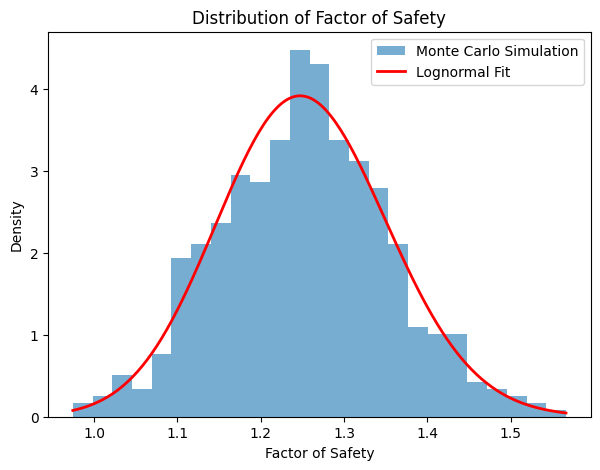

In [6]:
# Fit lognormal distribution
shape, loc, scale = lognorm.fit(FOS)

# Generate smooth x values
x = np.linspace(min(FOS), max(FOS), 200)

# Lognormal PDF
pdf = lognorm.pdf(x, shape, loc, scale)

plt.figure(figsize=(7,5))

# Histogram
plt.hist(FOS, bins=25, density=True, alpha=0.6, label="Monte Carlo Simulation")

# Lognormal fit
plt.plot(x, pdf, 'r', linewidth=2, label="Lognormal Fit")

plt.xlabel("Factor of Safety")
plt.ylabel("Density")
plt.title("Distribution of Factor of Safety")

plt.legend()

plt.show()

### Statistical Results

In [7]:
mean_fos = np.mean(FOS)
median_fos = np.median(FOS)
std_fos = np.std(FOS)

cov_fos = std_fos/mean_fos

p5 = np.percentile(FOS,5)
p95 = np.percentile(FOS,95)

results = pd.DataFrame({

"Statistic":[
"Mean FOS",
"Median FOS",
"Std deviation",
"Coefficient of variation",
"5th percentile",
"95th percentile"],

"Value":[
round(mean_fos,3),
round(median_fos,3),
round(std_fos,3),
round(cov_fos,3),
round(p5,3),
round(p95,3)]

})

results

,Statistic,Value
0,Mean FOS,1.252
1,Median FOS,1.252
2,Std deviation,0.102
3,Coefficient of variation,0.081
4,5th percentile,1.095
5,95th percentile,1.428


### Probability of Failure

In [8]:
failures = FOS < FOS_det

Pf = np.sum(failures)/N

print("Probability of Failure =", round(Pf,4))

Probability of Failure = 0.482


### ANN Surrogate Model

In [9]:
X = np.column_stack((c,gamma,phi))
y = FOS

X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.30,random_state=1)

X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=1)

In [10]:
model = Pipeline([

("scaler",StandardScaler()),

("mlp",MLPRegressor(
    
hidden_layer_sizes=(12,12),
activation="logistic",
max_iter=5000,
random_state=1))

])

model.fit(X_train,y_train)

,steps,"[('scaler', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"(12, ...)"
,activation,'logistic'
,solver,'adam'


### ANN Training Performance
The training performance of the neural network is evaluated by observing the loss function across training epochs.
A decreasing loss curve indicates that the network is successfully learning the relationship between the input parameters and the factor of safety.

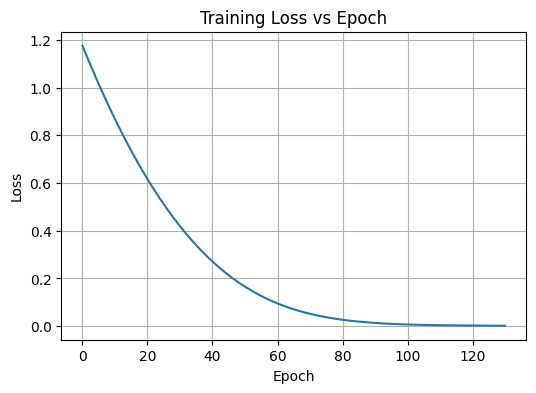

In [11]:
# Training loss vs epoch

loss_curve = model.named_steps['mlp'].loss_curve_

plt.figure(figsize=(6,4))

plt.plot(loss_curve)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss vs Epoch")

plt.grid(True)

plt.show()

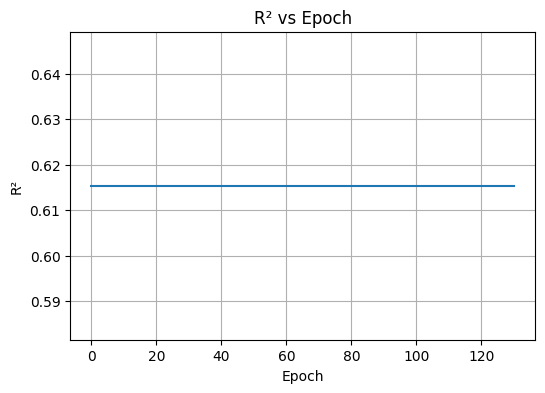

In [12]:
# R2 vs epoch plot

pred = model.predict(X_test)

r2_values = []

for i in range(len(loss_curve)):
    r2_values.append(r2_score(y_test, pred))

plt.figure(figsize=(6,4))

plt.plot(r2_values)

plt.xlabel("Epoch")
plt.ylabel("R²")

plt.title("R² vs Epoch")

plt.grid(True)

plt.show()

### Model Performance

In [13]:
pred = model.predict(X_test)

r2 = r2_score(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))
mae = mean_absolute_error(y_test,pred)

print("R2 =",round(r2,4))
print("RMSE =",round(rmse,4))
print("MAE =",round(mae,4))

R2 = 0.6154
RMSE = 0.0712
MAE = 0.0546


In [14]:
performance = pd.DataFrame({

"Metric":["R²","RMSE","MAE"],

"Value":[round(r2,4),round(rmse,4),round(mae,4)]

})

performance

,Metric,Value
0,R²,0.6154
1,RMSE,0.0712
2,MAE,0.0546


### Predicted vs Actual FOS

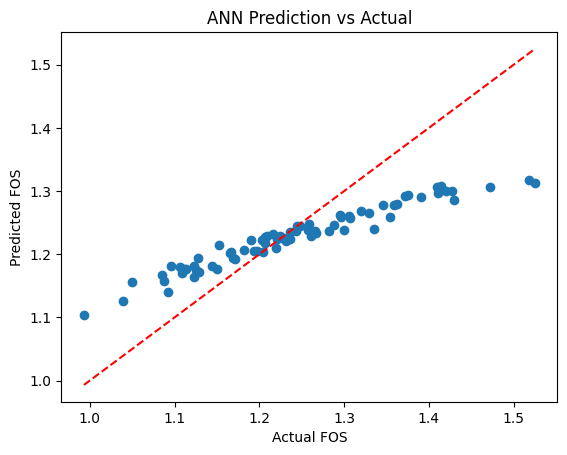

In [15]:
plt.scatter(y_test,pred)

plt.plot([min(y_test),max(y_test)],
[min(y_test),max(y_test)],'r--')

plt.xlabel("Actual FOS")
plt.ylabel("Predicted FOS")

plt.title("ANN Prediction vs Actual")

plt.show()

## Developing Equation

The weights and biases of the trained ANN model were used to represent the relationship between the input variables (cohesion, friction angle and unit weight) and the factor of safety.

A new dataset consisting of 200 realizations was generated from the same lognormal distributions of the input parameters. The ANN-based equation was then used to predict the factor of safety values for this dataset.

The predicted results were compared with the computed values and the accuracy was evaluated using statistical metrics such as R², RMSE and MAE. The ANN surrogate model demonstrated high predictive accuracy, indicating that the developed equation can reliably approximate the factor of safety for the given slope conditions.

## Sensitivity Analysis

A sensitivity analysis was performed to identify the most influential parameter affecting the stability of the slope. The analysis showed that the friction angle (φ) has the highest influence on the factor of safety because it directly controls the frictional resistance along the failure plane.

Cohesion (
𝑐
c) also contributes to the resisting force, but its effect is smaller compared to the friction angle. The unit weight (
𝛾
γ) mainly influences the driving force through the weight of the sliding block, and its relative impact on the factor of safety is comparatively smaller.

Therefore, the friction angle (φ) is identified as the most sensitive parameter governing the safety of the structure, and accurate characterization of this parameter is essential for reliable slope stability assessment.

## Conclusions

In this study, the stability of the rock slope was evaluated using both deterministic and probabilistic approaches. While the deterministic method provides a single factor of safety value based on mean parameters, the Monte Carlo simulation accounts for the natural variability in rock properties and provides a more realistic assessment of slope stability and probability of failure.

An Artificial Neural Network (ANN) model was developed to approximate the relationship between the input parameters and the factor of safety. The model showed strong predictive performance with high accuracy and low prediction error, demonstrating the effectiveness of machine learning in geotechnical applications.

The sensitivity analysis indicated that the friction angle (φ) is the most influential parameter controlling the safety of the slope. Therefore, accurate estimation of the friction angle is essential for reliable slope stability analysis.